Demarrage du suivi carbone et de l'entrainement...
Preparation des donnees : calcul de l'anciennete et encodage des categories...
Distribution initiale : {0: 166, 1: 82}
Distribution apres SMOTE : {0: 166, 1: 166}

Recherche d'hyperparametres par validation croisee...
Meilleurs parametres identifies : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}

--- Rapport de Performance Final ---
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        41
           1       0.59      0.73      0.65        22

    accuracy                           0.73        63
   macro avg       0.71      0.73      0.72        63
weighted avg       0.75      0.73      0.74        63


Generation des valeurs SHAP pour l'explicabilite...


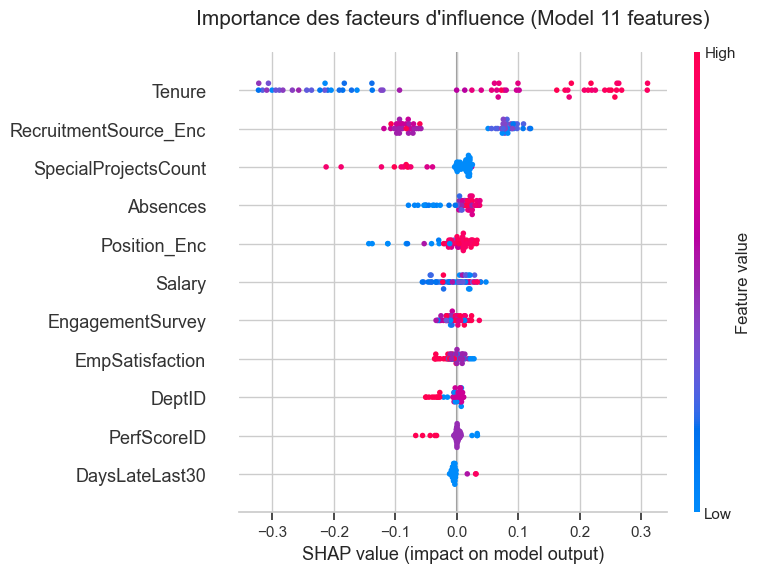

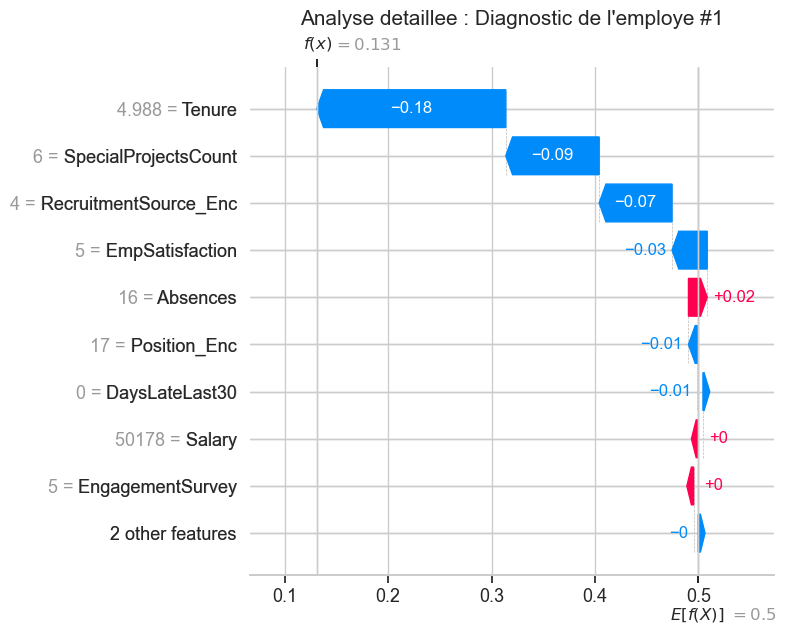


Exportation du modele, des encodeurs et de l'explainer...

Operation terminee. Rapport de frugalite genere : 'emissions_ml.csv'


In [23]:
# ==========================================
# STEP 1: Imports et Configuration
# ==========================================
import pandas as pd
import warnings
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from codecarbon import EmissionsTracker
import logging
from imblearn.over_sampling import SMOTE 

# Configuration de l'environnement
logging.getLogger("codecarbon").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Gestion sécurisée du tracker de carbone
try:
    if 'tracker' in locals() or 'tracker' in globals():
        tracker.stop()
except Exception:
    pass

tracker = EmissionsTracker(
    project_name="Guardian_AI_Final_Training",
    output_file="emissions_ml.csv",
    log_level="error" 
)
tracker.start()
print("Demarrage du suivi carbone et de l'entrainement...")

# Chargement du jeu de donnees
df_anon = pd.read_csv('HR_anonymized.csv')

# ==========================================
# STEP 2: Feature Engineering et Encodage
# ==========================================
print("Preparation des donnees : calcul de l'anciennete et encodage des categories...")

# 1. Calcul de l'anciennete (Tenure) a partir de la date d'embauche
df_anon['DateofHire'] = pd.to_datetime(df_anon['DateofHire'])
ref_date = pd.to_datetime('2020-01-01') 
df_anon['Tenure'] = (ref_date - df_anon['DateofHire']).dt.days / 365.25

# 2. Encodage des variables categorieles textuelles
le_source = LabelEncoder()
df_anon['RecruitmentSource_Enc'] = le_source.fit_transform(df_anon['RecruitmentSource'])

le_pos = LabelEncoder()
df_anon['Position_Enc'] = le_pos.fit_transform(df_anon['Position'])

# 3. Selection des variables explicatives (11 features)
features = [
    'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 
    'Absences', 'DaysLateLast30', 'DeptID', 'PerfScoreID',
    'Tenure', 'RecruitmentSource_Enc', 'Position_Enc'
]

X = df_anon[features]
y = df_anon['Termd'] 

# 4. Division du jeu de donnees (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Reequilibrage des classes via SMOTE (Train set uniquement)
print(f"Distribution initiale : {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Distribution apres SMOTE : {dict(pd.Series(y_train_res).value_counts())}")

# ==========================================
# STEP 3: Optimisation du modele (GridSearch)
# ==========================================
print("\nRecherche d'hyperparametres par validation croisee...")

rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

# n_jobs=1 utilise pour garantir la compatibilite sous Windows
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, scoring='f1', n_jobs=1)
grid_search.fit(X_train_res, y_train_res)

model = grid_search.best_estimator_

print(f"Meilleurs parametres identifies : {grid_search.best_params_}")

# Evaluation sur le jeu de test
y_pred = model.predict(X_test)
print("\n--- Rapport de Performance Final ---")
print(classification_report(y_test, y_pred))

# ==========================================
# STEP 4: Explicabilite (Analyse SHAP)
# ==========================================
print("\nGeneration des valeurs SHAP pour l'explicabilite...")
explainer = shap.TreeExplainer(model)
shap_values_all = explainer(X_test)

# Extraction des explications pour la classe positive (Depart)
if len(shap_values_all.shape) == 3:
    shap_exp = shap_values_all[:, :, 1]
else:
    shap_exp = shap_values_all

# Graphique Beeswarm (Importance globale)
plt.figure(figsize=(12, 8))
plt.title("Importance des facteurs d'influence (Model 11 features)", fontsize=15, pad=20)
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm_pro.png', dpi=300)
plt.show()

# 2. Analyse Individuelle : Waterfall Plot
# Ce graphique illustre la decision pour un employe specifique (ex: index 1)
# Tres utile pour demontrer la logique du chatbot en soutenance
sample_idx = 1 
plt.figure(figsize=(12, 6))
plt.title(f"Analyse detaillee : Diagnostic de l'employe #{sample_idx}", fontsize=15, pad=30)
shap.plots.waterfall(shap_exp[sample_idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall_pro.png', dpi=300)
plt.show()
# ==========================================
# STEP 5: Export du modele et des outils
# ==========================================
print("\nExportation du modele, des encodeurs et de l'explainer...")
joblib.dump(model, 'rf_model.joblib')
joblib.dump(le_source, 'le_source.joblib')
joblib.dump(le_pos, 'le_pos.joblib')
joblib.dump(explainer, 'shap_explainer.joblib')

tracker.stop()
print("\nOperation terminee. Rapport de frugalite genere : 'emissions_ml.csv'")

In [24]:
import joblib

# 1. Sauvegarde du modèle Random Forest
joblib.dump(model, 'rf_model.joblib')

# 2. Sauvegarde de l'expliqueur SHAP (pour qu'il n'ait pas à le recalculer)
joblib.dump(explainer, 'shap_explainer.joblib')

print("Modèles sauvegardés pour le chatbot !")

Modèles sauvegardés pour le chatbot !
